In [40]:
import sys

print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
d:\Spam-classifier\.venv\Scripts\python.exe


Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


Load dataset

In [42]:
df = pd.read_csv("../data/raw/enron_spam_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (33716, 5)


In [43]:
df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


Dataset Understatnding

In [44]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 33716
Columns: 5


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


In [46]:
df["Spam/Ham"].value_counts()

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

In [47]:
df["Spam/Ham"].value_counts(normalize=True) * 100

Spam/Ham
spam    50.928343
ham     49.071657
Name: proportion, dtype: float64

In [48]:
df.isnull().sum()

Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

In [49]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [50]:
df["Spam/Ham"].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

Understanding Email Length

In [51]:
df["Subject_Length"] = df["Subject"].fillna("").str.len()
df["Message_Length"] = df["Message"].fillna("").str.len()

In [52]:
df.groupby("Spam/Ham")[["Subject_Length", "Message_Length"]].describe()

Subject_Length                                                       \
                  count       mean        std  min   25%   50%   75%     max   
Spam/Ham                                                                       
ham             16545.0  31.153823  26.288072  1.0  18.0  28.0  41.0  1355.0   
spam            17171.0  37.869955  53.649735  0.0  22.0  34.0  47.0  3153.0   

         Message_Length                                                       \
                  count         mean          std  min    25%    50%     75%   
Spam/Ham                                                                       
ham             16545.0  1676.289211  5774.643156  0.0  308.0  766.0  1665.0   
spam            17171.0  1271.866053  1953.997315  0.0  308.0  605.0  1333.0   

                    
               max  
Spam/Ham            
ham       228353.0  
spam       28688.0

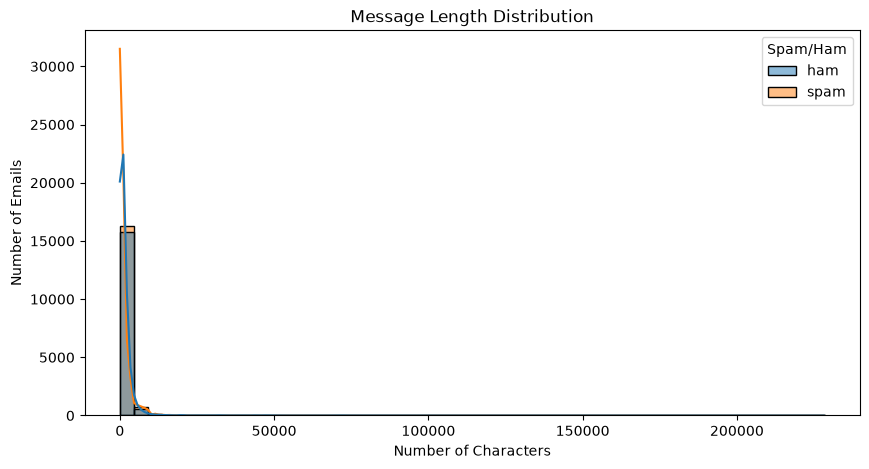

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Message_Length",
    hue="Spam/Ham",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")
plt.show()

Check duplicate emails`

In [54]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate messages:", df["Message"].duplicated().sum())
print("Duplicate subjects:", df["Subject"].duplicated().sum())

Duplicate rows: 0
Duplicate messages: 3936
Duplicate subjects: 9509


In [55]:
duplicate_messages = (
    df.groupby("Message")["Spam/Ham"]
      .nunique()
)

print("Messages appearing with multiple labels:",
      (duplicate_messages > 1).sum())

conflicting_messages = (
    df.groupby("Message")["Spam/Ham"]
      .nunique()
)

conflicting_messages = conflicting_messages[
    conflicting_messages > 1
]

print(conflicting_messages)

Messages appearing with multiple labels: 1
Message
hi    2
Name: Spam/Ham, dtype: int64


In [56]:
df[df["Message"] == "hi"][["Subject", "Message", "Spam/Ham", "Date"]]

,Subject,Message,Spam/Ham,Date
7136,elena chilkina,hi,ham,2000-10-04
15166,chess board widows living with 3481,hi,spam,2004-09-14
29657,chess board widows living with 3481,hi,spam,2004-09-14


In [57]:
df.loc[[15166, 29657]]

,Message ID,Subject,Message,Spam/Ham,Date,Subject_Length,Message_Length
15166,15166,chess board widows living with 3481,hi,spam,2004-09-14,35,2
29657,29657,chess board widows living with 3481,hi,spam,2004-09-14,35,2


In [58]:
df.loc[15166].equals(df.loc[29657])

False

In [59]:
df.loc[15166, ["Subject", "Message", "Spam/Ham", "Date"]].equals(
    df.loc[29657, ["Subject", "Message", "Spam/Ham", "Date"]]
)

True

In [60]:
df = df.drop_duplicates(
    subset=["Subject", "Message", "Spam/Ham", "Date"]
).reset_index(drop=True)

In [61]:
print("New shape:", df.shape)
print("Duplicate email records:", 
      df.duplicated(
          subset=["Subject", "Message", "Spam/Ham", "Date"]
      ).sum())

New shape: (30763, 7)
Duplicate email records: 0


In [62]:
df["Spam/Ham"].value_counts()

Spam/Ham
ham     15951
spam    14812
Name: count, dtype: int64

In [63]:
df["Spam/Ham"].value_counts(normalize=True) * 100

Spam/Ham
ham     51.85125
spam    48.14875
Name: proportion, dtype: float64

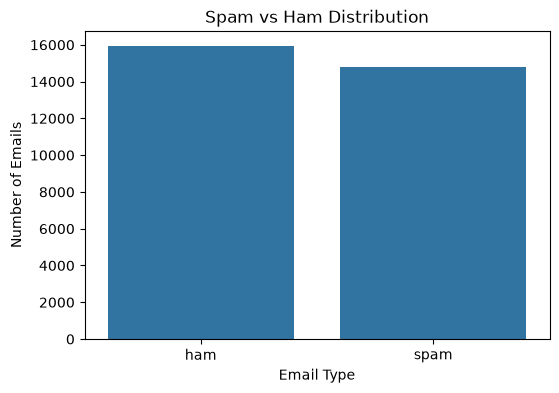

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Spam/Ham"
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.show()

In [65]:
class_distribution = (
    df["Spam/Ham"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_distribution)

Spam/Ham
ham     51.85
spam    48.15
Name: proportion, dtype: float64


In [66]:
df["Text"] = (
    df["Subject"].fillna("") + " " +
    df["Message"].fillna("")
)

In [67]:
df[["Subject", "Message", "Text", "Spam/Ham"]].head()

,Subject,Message,Text,Spam/Ham
0,christmas tree farm pictures,NaN,christmas tree farm pictures,ham
1,"vastar resources , inc .","gary , production from the high island larger ...","vastar resources , inc . gary , production fro...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,calpine daily gas nomination - calpine daily g...,ham
3,re : issue,fyi - see note below - already done .\nstella\...,re : issue fyi - see note below - already done...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,meter 7268 nov allocation fyi .\n- - - - - - -...,ham


In [68]:
df["Word_Count"] = df["Text"].str.split().str.len()

df.groupby("Spam/Ham")["Word_Count"].describe()

,count,mean,std,min,25%,50%,75%,max
Spam/Ham,,,,,,,,
ham,15951.0,345.766222,1073.821371,1.0,73.0,173.0,367.0,45450.0
spam,14812.0,258.853970,380.227814,0.0,70.0,135.0,272.0,8401.0


Observation: Ham emails have a higher median and mean word count than spam emails. Both distributions contain long-text outliers, particularly ham emails. Therefore, word count alone is not sufficient for classification, and the actual email text will be used as the primary feature.

In [69]:
df.to_csv("../data/processed/emails_cleaned.csv", index=False)

In [70]:
print("Saved shape:", df.shape)

Saved shape: (30763, 9)
